<a href="https://colab.research.google.com/github/mp1605/CS-4410-Intro-to-Machine-Learning-/blob/main/Homework_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework7

Exercises 16.1 and 16.4: CNN Dataset and Dense-Layer Comparisons

**16.1:** Train the chapter CNN on MNIST and Fashion-MNIST and compare test accuracy and training time.  
**16.4:** On MNIST, compare the chapter CNN with (a) its first Dense layer removed and (b) a new 4096-neuron Dense layer inserted before its original two Dense layers.



In [1]:
# Colab normally already includes these packages. Install only if missing.
import importlib.util
import subprocess
import sys
packages = {'tensorflow': 'tensorflow', 'numpy': 'numpy',
            'pandas': 'pandas', 'matplotlib': 'matplotlib'}
missing = [package for module, package in packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
print('Dependencies ready.')

Dependencies ready.


In [2]:
import os
from pathlib import Path
# Keep downloaded datasets in this notebook's working directory.
os.environ.setdefault('KERAS_HOME', str(Path('keras_cache').resolve()))
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
import time
import gc
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

SEED = 11
EPOCHS = 5
BATCH_SIZE = 64
# Apply the same resource settings to every experiment.
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(2)
tf.keras.utils.set_random_seed(SEED)
print('Python:', platform.python_version())
print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))
print('Epochs:', EPOCHS, '| Batch size:', BATCH_SIZE)

Python: 3.13.15
TensorFlow: 2.20.0
GPUs: []
Epochs: 5 | Batch size: 64


## 1. Load and inspect both datasets
Each dataset supplies 60,000 training images and 10,000 test images. Retain the official test sets. As in the reference's `validation_split=0.1`, reserve the last 6,000 training images for validation; 54,000 images are used for weight updates.

Dataset loading and preprocessing are outside the model training timer.

In [3]:
raw = {'MNIST': mnist.load_data(), 'Fashion-MNIST': fashion_mnist.load_data()}
fashion_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
class_names = {'MNIST': [str(i) for i in range(10)], 'Fashion-MNIST': fashion_names}
for name, ((x_train, y_train), (x_test, y_test)) in raw.items():
    print(name)
    print('Training images/labels:', x_train.shape, y_train.shape)
    print('Testing images/labels:', x_test.shape, y_test.shape)
    assert x_train.shape == (60000, 28, 28)
    assert x_test.shape == (10000, 28, 28)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST
Training images/labels: (60000, 28, 28) (60000,)
Testing images/labels: (10000, 28, 28) (10000,)
Fashion-MNIST
Training images/labels: (60000, 28, 28) (60000,)
Testing images/labels: (10000, 28, 28) (10000,)


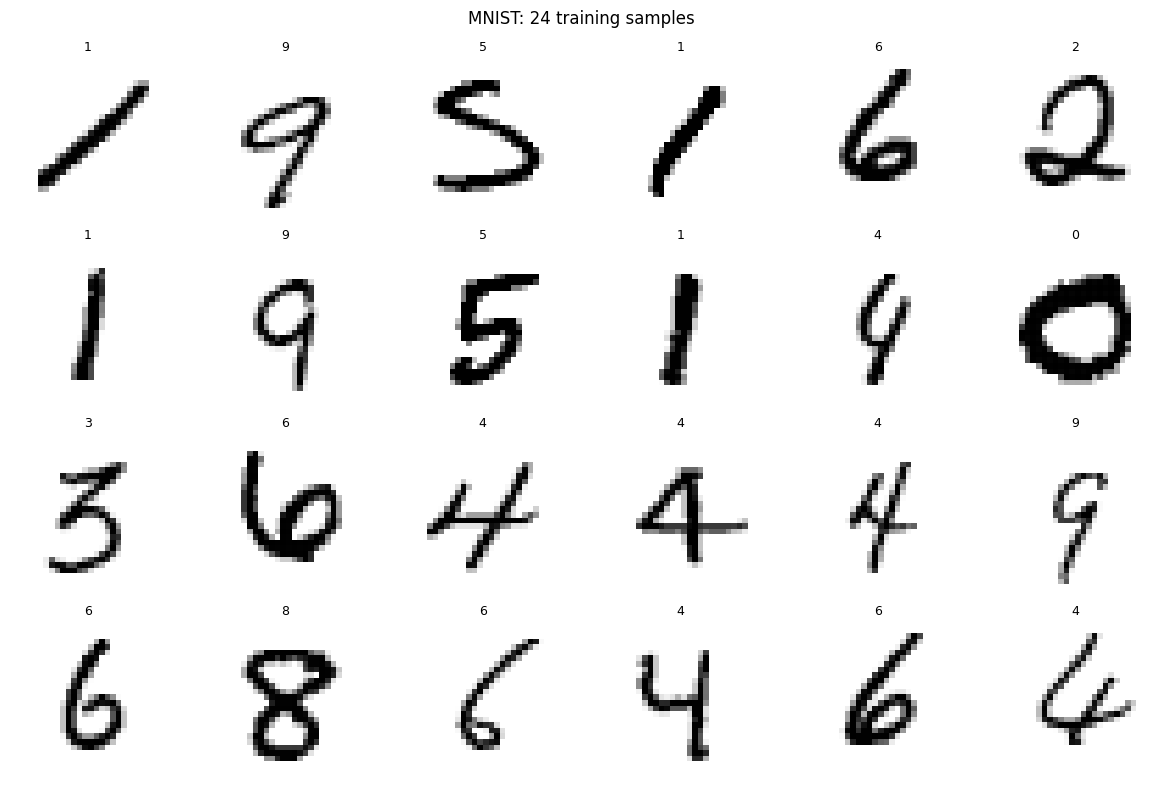

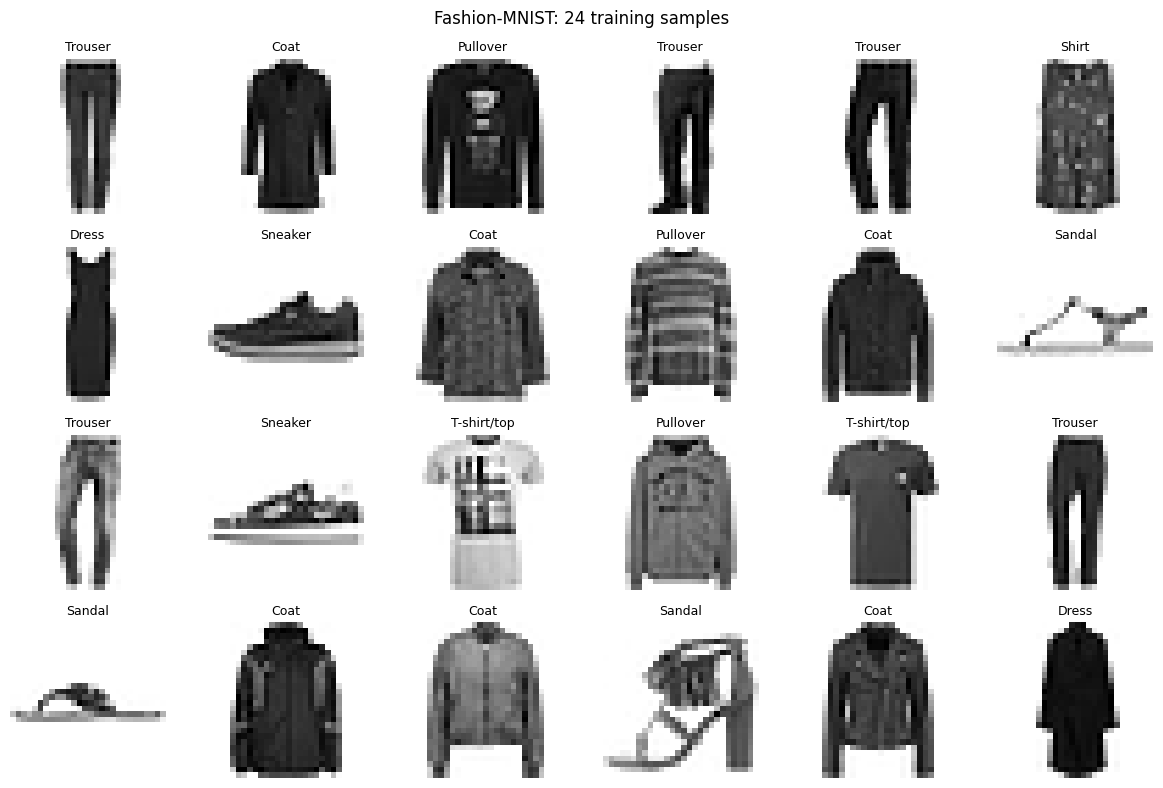

In [4]:
for name, ((x_train, y_train), _) in raw.items():
    indices = np.random.default_rng(SEED).choice(len(x_train), 24, replace=False)
    fig, axes = plt.subplots(4, 6, figsize=(12, 8))
    for ax, index in zip(axes.flat, indices):
        ax.imshow(x_train[index], cmap='gray_r')
        ax.set_title(class_names[name][int(y_train[index])], fontsize=9)
        ax.axis('off')
    fig.suptitle(name + ': 24 training samples')
    plt.tight_layout()
    plt.show()

## 2. Prepare data as in the chapter
Reshape to `(samples, 28, 28, 1)`, convert pixels to `float32`, divide by 255, and one-hot encode labels into 10 columns. No augmentation or additional regularization is introduced.

The data below is batched with `tf.data` to limit background threads in constrained environments. Its explicit validation holdout matches the chapter's last-10% split; batching remains 64 and training data is shuffled each epoch.

In [5]:
def prepare_data(dataset_name):
    (x_train, y_train), (x_test, y_test) = raw[dataset_name]
    x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255
    x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255
    y_train = to_categorical(y_train, 10).astype('float32')
    y_test = to_categorical(y_test, 10).astype('float32')
    return x_train, y_train, x_test, y_test

def batches(x, y=None, training=False):
    values = x if y is None else (x, y)
    ds = tf.data.Dataset.from_tensor_slices(values)
    if training:
        ds = ds.shuffle(len(x), seed=SEED, reshuffle_each_iteration=True)
    options = tf.data.Options()
    options.threading.private_threadpool_size = 2
    options.threading.max_intra_op_parallelism = 2
    return ds.batch(BATCH_SIZE).with_options(options).prefetch(1)

x_demo, y_demo, xt_demo, yt_demo = prepare_data('Fashion-MNIST')
print('Prepared training:', x_demo.shape, y_demo.shape)
print('Prepared testing:', xt_demo.shape, yt_demo.shape)
print('Pixel range:', x_demo.min(), x_demo.max())
print('First one-hot label:', y_demo[0])
del x_demo, y_demo, xt_demo, yt_demo

Prepared training: (60000, 28, 28, 1) (60000, 10)
Prepared testing: (10000, 28, 28, 1) (10000, 10)
Pixel range: 0.0 1.0
First one-hot label: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


## 3. Define the chapter CNN and the two requested variations
All models share: `Conv2D(64, 3×3, ReLU) → MaxPool(2×2) → Conv2D(128, 3×3, ReLU) → MaxPool(2×2) → Flatten`.

| Variant | Dense layers after Flatten |
|---|---|
| Baseline | Dense(128, ReLU) → Dense(10, softmax) |
| Remove Dense(128) | Dense(10, softmax) |
| Add Dense(4096) | Dense(4096, ReLU) → Dense(128, ReLU) → Dense(10, softmax) |

The output layer always stays in place. The large-layer experiment starts from the original model, not the model with Dense(128) removed. An explicit `Input` layer is the modern equivalent of the reference's first-layer `input_shape` argument.

In [6]:
def make_model(variant='Baseline'):
    model = Sequential([
        Input(shape=(28, 28, 1)),
        Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten()
    ])
    if variant == 'Add Dense(4096)':
        model.add(Dense(units=4096, activation='relu'))
    if variant != 'Remove Dense(128)':
        model.add(Dense(units=128, activation='relu'))
    model.add(Dense(units=10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

for variant in ['Baseline', 'Remove Dense(128)', 'Add Dense(4096)']:
    print('\nVARIANT:', variant)
    model = make_model(variant)
    model.summary()
    del model
    tf.keras.backend.clear_session()


VARIANT: Baseline


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,514 (1.85 MB)

 Trainable params: 485,514 (1.85 MB)

...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    13,111,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,711,498 (52.31 MB)

 Trainable params: 13,711,498 (52.31 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Train and measure each model
Training time measures `fit`, including all five epochs, validation, and initial graph setup. It excludes downloading, preparation, model construction, plotting, and saving. A prediction warm-up occurs before timing three full passes over the 10,000 test images; report the median time. The same batch size, hardware, and thread settings apply to all runs.

These are single training runs with a fixed seed, not averaged accuracy benchmarks. Small accuracy differences may be due to initialization and training variation. Prediction timing includes Keras/data-iteration overhead, so it describes this batched workflow.

In [7]:
results = []
histories = {}
outputs = {}

def run_experiment(dataset_name, variant):
    tf.keras.backend.clear_session()
    gc.collect()
    tf.keras.utils.set_random_seed(SEED)
    x_train, y_train, x_test, y_test = prepare_data(dataset_name)
    train_ds = batches(x_train[:54000], y_train[:54000], training=True)
    val_ds = batches(x_train[54000:], y_train[54000:])
    test_ds = batches(x_test, y_test)
    predict_ds = batches(x_test)
    model = make_model(variant)
    print('\nTRAINING:', dataset_name, '|', variant, flush=True)
    start = time.perf_counter()
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)
    train_seconds = time.perf_counter() - start
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
    model.predict(batches(x_test[:BATCH_SIZE]), verbose=0)  # warm-up
    prediction_times = []
    for _ in range(3):
        start = time.perf_counter()
        probabilities = model.predict(predict_ds, verbose=0)
        prediction_times.append(time.perf_counter() - start)
    predict_seconds = float(np.median(prediction_times))
    predicted = probabilities.argmax(axis=1)
    expected = y_test.argmax(axis=1)
    assert np.isclose((predicted == expected).mean(), test_accuracy, atol=1e-6)
    row = {'Dataset': dataset_name, 'Variant': variant,
           'Parameters': model.count_params(), 'Test accuracy (%)': test_accuracy * 100,
           'Test loss': test_loss, 'Training (s)': train_seconds,
           'Seconds/epoch': train_seconds / EPOCHS,
           'Predict 10000 (s)': predict_seconds,
           'Images/second': len(x_test) / predict_seconds}
    results.append(row)
    key = (dataset_name, variant)
    histories[key] = history.history
    outputs[key] = probabilities
    if variant == 'Baseline':
        filename = 'fashion_mnist_cnn.keras' if dataset_name == 'Fashion-MNIST' else 'mnist_cnn.keras'
        model.save(filename)
        print('Saved:', filename)
    print(pd.DataFrame([row]).round(4).to_string(index=False), flush=True)
    del model, x_train, y_train, x_test, y_test, train_ds, val_ds, test_ds, predict_ds
    gc.collect()

In [8]:
run_experiment('MNIST', 'Baseline')


TRAINING: MNIST | Baseline
Epoch 1/5
844/844 - 101s - 120ms/step - accuracy: 0.9560 - loss: 0.1434 - val_accuracy: 0.9867 - val_loss: 0.0481
Epoch 2/5
844/844 - 137s - 162ms/step - accuracy: 0.9859 - loss: 0.0438 - val_accuracy: 0.9883 - val_loss: 0.0410
Epoch 3/5
844/844 - 143s - 169ms/step - accuracy: 0.9906 - loss: 0.0299 - val_accuracy: 0.9907 - val_loss: 0.0351
Epoch 4/5
844/844 - 141s - 167ms/step - accuracy: 0.9931 - loss: 0.0211 - val_accuracy: 0.9908 - val_loss: 0.0318
Epoch 5/5
844/844 - 95s - 112ms/step - accuracy: 0.9950 - loss: 0.0155 - val_accuracy: 0.9895 - val_loss: 0.0366
Saved: mnist_cnn.keras
Dataset  Variant  Parameters  Test accuracy (%)  Test loss  Training (s)  Seconds/epoch  Predict 10000 (s)  Images/second
  MNIST Baseline      485514               99.0     0.0282      664.0731       132.8146             4.0232       2485.553


In [9]:
run_experiment('Fashion-MNIST', 'Baseline')


TRAINING: Fashion-MNIST | Baseline
Epoch 1/5
844/844 - 99s - 117ms/step - accuracy: 0.8337 - loss: 0.4601 - val_accuracy: 0.8665 - val_loss: 0.3580
Epoch 2/5
844/844 - 142s - 168ms/step - accuracy: 0.8896 - loss: 0.3029 - val_accuracy: 0.8888 - val_loss: 0.3008
Epoch 3/5
844/844 - 96s - 114ms/step - accuracy: 0.9073 - loss: 0.2550 - val_accuracy: 0.9043 - val_loss: 0.2642
Epoch 4/5
844/844 - 141s - 167ms/step - accuracy: 0.9180 - loss: 0.2215 - val_accuracy: 0.9107 - val_loss: 0.2546
Epoch 5/5
844/844 - 97s - 115ms/step - accuracy: 0.9275 - loss: 0.1945 - val_accuracy: 0.9142 - val_loss: 0.2475
Saved: fashion_mnist_cnn.keras
      Dataset  Variant  Parameters  Test accuracy (%)  Test loss  Training (s)  Seconds/epoch  Predict 10000 (s)  Images/second
Fashion-MNIST Baseline      485514              90.87      0.262      620.5736       124.1147             3.9715      2517.9524


In [10]:
run_experiment('MNIST', 'Remove Dense(128)')


TRAINING: MNIST | Remove Dense(128)
Epoch 1/5
844/844 - 93s - 110ms/step - accuracy: 0.9494 - loss: 0.1691 - val_accuracy: 0.9840 - val_loss: 0.0531
Epoch 2/5
844/844 - 91s - 108ms/step - accuracy: 0.9836 - loss: 0.0527 - val_accuracy: 0.9860 - val_loss: 0.0443
Epoch 3/5
844/844 - 92s - 109ms/step - accuracy: 0.9882 - loss: 0.0379 - val_accuracy: 0.9878 - val_loss: 0.0390
Epoch 4/5
844/844 - 92s - 109ms/step - accuracy: 0.9908 - loss: 0.0287 - val_accuracy: 0.9883 - val_loss: 0.0377
Epoch 5/5
844/844 - 142s - 168ms/step - accuracy: 0.9929 - loss: 0.0223 - val_accuracy: 0.9892 - val_loss: 0.0401
Dataset           Variant  Parameters  Test accuracy (%)  Test loss  Training (s)  Seconds/epoch  Predict 10000 (s)  Images/second
  MNIST Remove Dense(128)      106506              98.85     0.0316      509.9265       101.9853             3.8671      2585.9431


In [11]:
run_experiment('MNIST', 'Add Dense(4096)')


TRAINING: MNIST | Add Dense(4096)
Epoch 1/5
844/844 - 324s - 384ms/step - accuracy: 0.9626 - loss: 0.1194 - val_accuracy: 0.9852 - val_loss: 0.0488
Epoch 2/5
844/844 - 381s - 451ms/step - accuracy: 0.9872 - loss: 0.0400 - val_accuracy: 0.9878 - val_loss: 0.0462
Epoch 3/5
844/844 - 321s - 380ms/step - accuracy: 0.9922 - loss: 0.0250 - val_accuracy: 0.9905 - val_loss: 0.0348
Epoch 4/5
844/844 - 324s - 384ms/step - accuracy: 0.9946 - loss: 0.0167 - val_accuracy: 0.9900 - val_loss: 0.0359
Epoch 5/5
844/844 - 339s - 402ms/step - accuracy: 0.9955 - loss: 0.0141 - val_accuracy: 0.9882 - val_loss: 0.0507
Dataset         Variant  Parameters  Test accuracy (%)  Test loss  Training (s)  Seconds/epoch  Predict 10000 (s)  Images/second
  MNIST Add Dense(4096)    13711498              98.83     0.0433     1689.1846       337.8369             9.8552        1014.69


## 5. Results and training curves

      Dataset           Variant  Parameters  Test accuracy (%)  Test loss  Training (s)  Seconds/epoch  Predict 10000 (s)  Images/second
        MNIST          Baseline      485514              99.00     0.0282      664.0731       132.8146             4.0232      2485.5530
Fashion-MNIST          Baseline      485514              90.87     0.2620      620.5736       124.1147             3.9715      2517.9524
        MNIST Remove Dense(128)      106506              98.85     0.0316      509.9265       101.9853             3.8671      2585.9431
        MNIST   Add Dense(4096)    13711498              98.83     0.0433     1689.1846       337.8369             9.8552      1014.6900


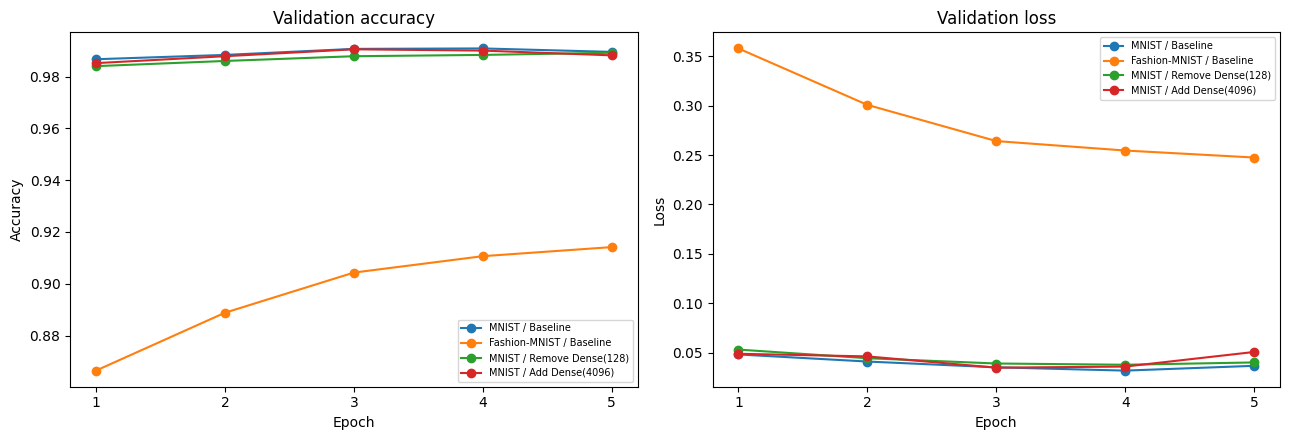

In [12]:
comparison = pd.DataFrame(results)
print(comparison.round(4).to_string(index=False))
comparison.to_csv('cnn_comparison.csv', index=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for key, history in histories.items():
    label = ' / '.join(key)
    epochs = range(1, EPOCHS + 1)
    axes[0].plot(epochs, history['val_accuracy'], marker='o', label=label)
    axes[1].plot(epochs, history['val_loss'], marker='o', label=label)
axes[0].set(title='Validation accuracy', xlabel='Epoch', ylabel='Accuracy')
axes[1].set(title='Validation loss', xlabel='Epoch', ylabel='Loss')
for ax in axes:
    ax.set_xticks(range(1, EPOCHS + 1))
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 6. Predictions and mistakes, following the chapter
Show the first test sample's probabilities and up to 24 misclassified test images for each baseline model. Fashion-MNIST plots use clothing names rather than digit labels.


First test image: MNIST
Actual: 7
0: 0.000000%
1: 0.000000%
2: 0.000010%
3: 0.000004%
4: 0.000000%
5: 0.000000%
6: 0.000000%
7: 99.999970%
8: 0.000000%
9: 0.000011%
Incorrect predictions: 100 of 10000


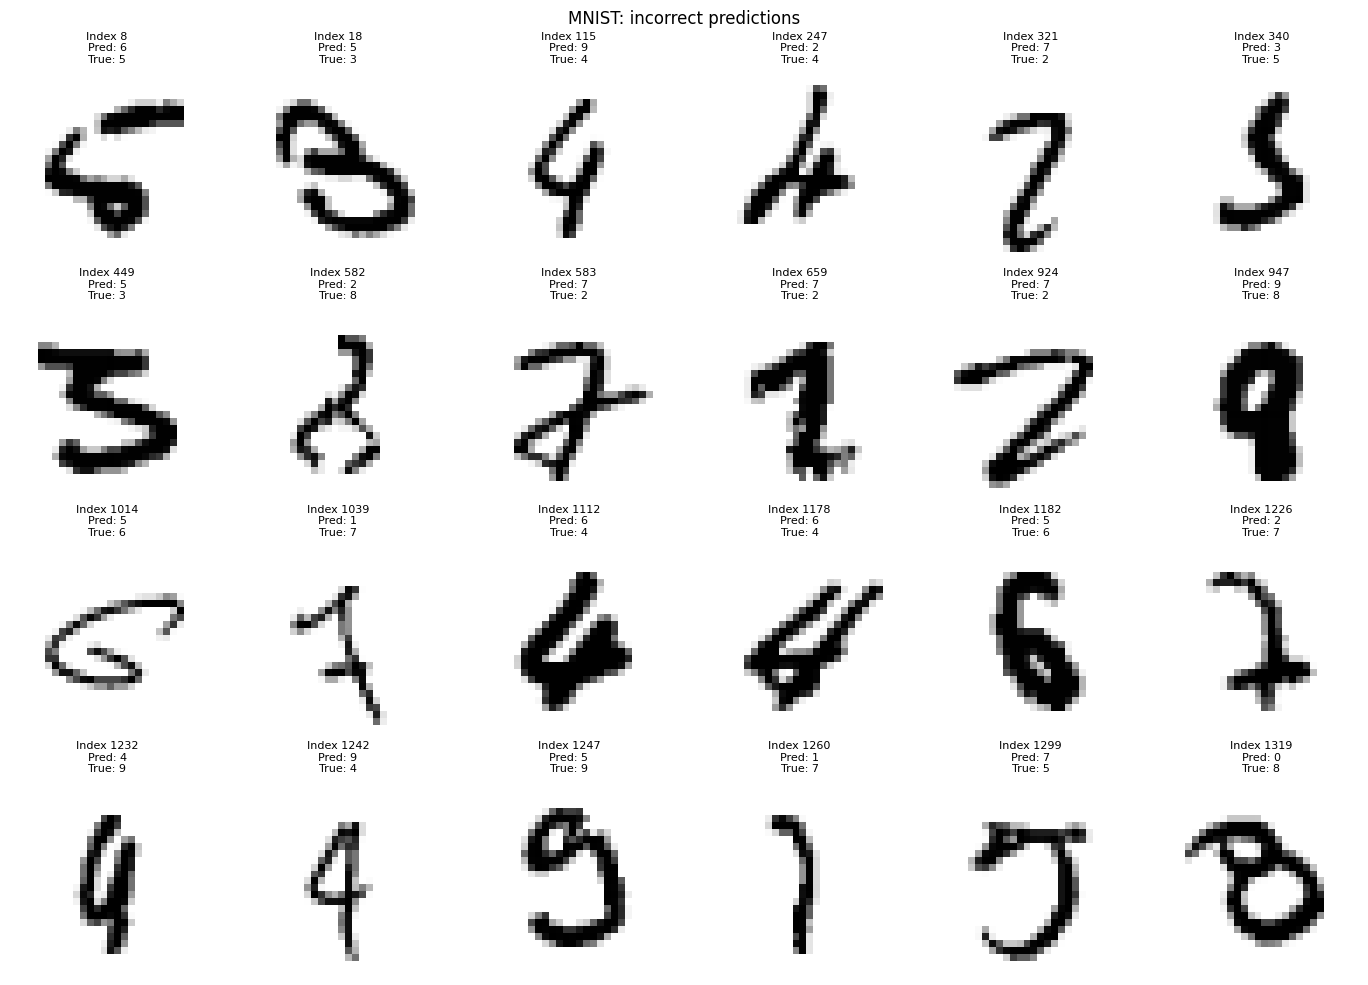


First test image: Fashion-MNIST
Actual: Ankle boot
T-shirt/top: 0.000017%
Trouser: 0.000002%
Pullover: 0.000198%
Dress: 0.000008%
Coat: 0.000145%
Sandal: 0.022902%
Shirt: 0.000016%
Sneaker: 0.444445%
Bag: 0.000112%
Ankle boot: 99.532157%
Incorrect predictions: 913 of 10000


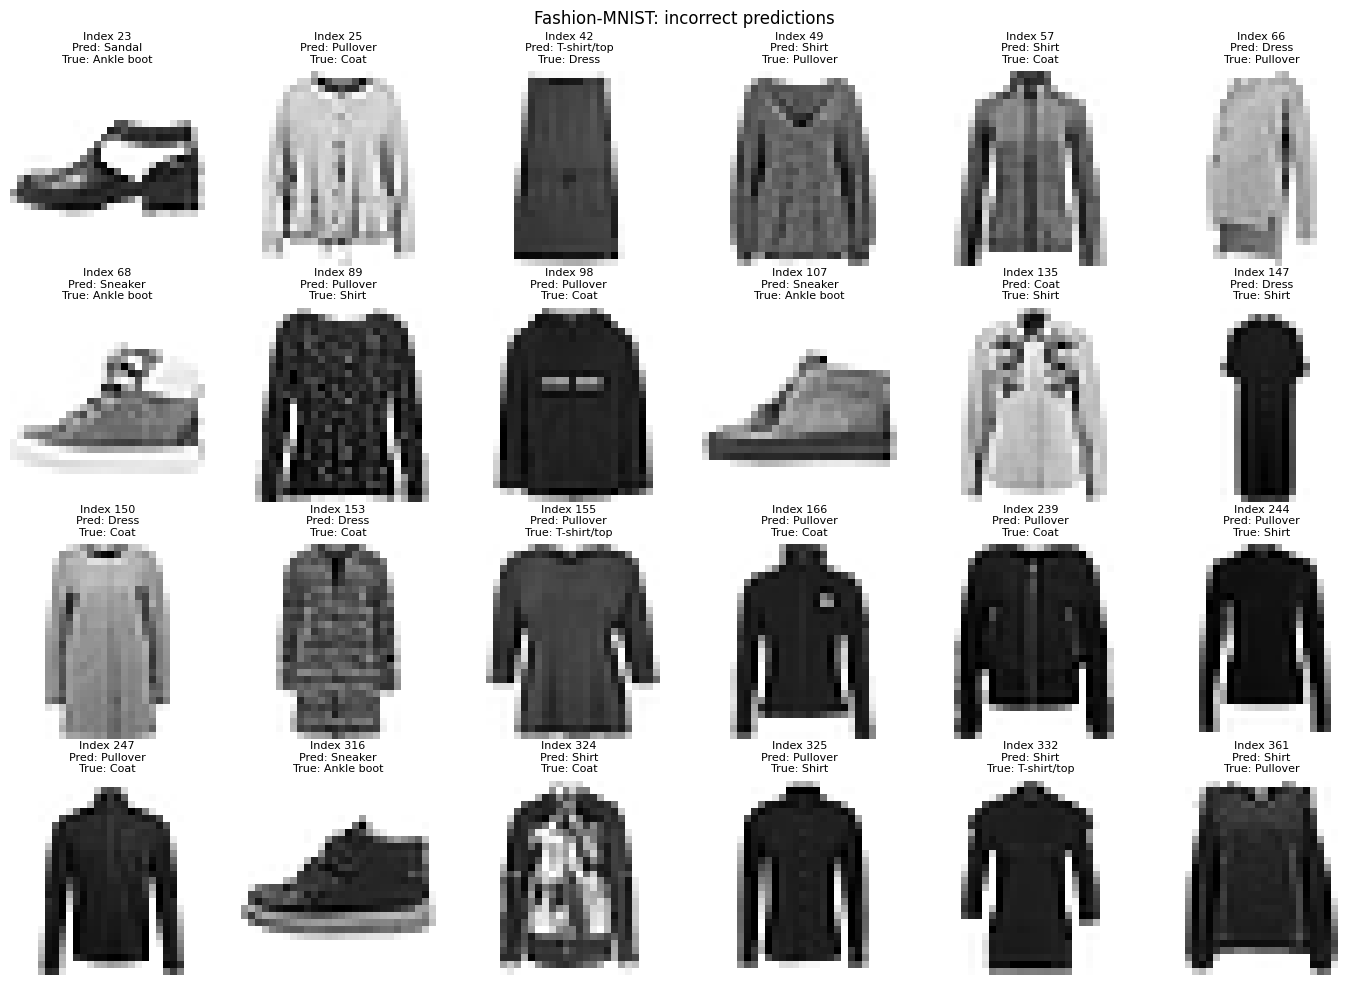

In [13]:
for dataset_name in ['MNIST', 'Fashion-MNIST']:
    probabilities = outputs[(dataset_name, 'Baseline')]
    (_, _), (images, expected) = raw[dataset_name]
    predicted = probabilities.argmax(axis=1)
    print('\nFirst test image:', dataset_name)
    print('Actual:', class_names[dataset_name][int(expected[0])])
    for label, probability in zip(class_names[dataset_name], probabilities[0]):
        print(f'{label}: {probability:.6%}')
    wrong = np.flatnonzero(predicted != expected)
    print('Incorrect predictions:', len(wrong), 'of', len(expected))
    fig, axes = plt.subplots(4, 6, figsize=(14, 10))
    for ax in axes.flat:
        ax.axis('off')
    for ax, index in zip(axes.flat, wrong[:24]):
        ax.imshow(images[index], cmap='gray_r')
        ax.set_title(f'Index {index}\nPred: {class_names[dataset_name][predicted[index]]}\nTrue: {class_names[dataset_name][expected[index]]}', fontsize=8)
    fig.suptitle(dataset_name + ': incorrect predictions')
    plt.tight_layout()
    plt.show()

## 7. Answers calculated from the measured results
Positive accuracy changes mean higher accuracy than the comparison baseline. A time ratio below 1 means faster; above 1 means slower.

In [14]:
base = comparison[(comparison.Dataset == 'MNIST') & (comparison.Variant == 'Baseline')].iloc[0]
fashion = comparison[comparison.Dataset == 'Fashion-MNIST'].iloc[0]
print('EXERCISE 16.1')
print(f"MNIST test accuracy: {base['Test accuracy (%)']:.2f}%.")
print(f"Fashion-MNIST test accuracy: {fashion['Test accuracy (%)']:.2f}%.")
print(f"Fashion-MNIST accuracy difference: {fashion['Test accuracy (%)'] - base['Test accuracy (%)']:+.2f} percentage points.")
print(f"Training time: MNIST {base['Training (s)']:.2f}s; Fashion-MNIST {fashion['Training (s)']:.2f}s.")
print(f"Fashion/MNIST training-time ratio: {fashion['Training (s)'] / base['Training (s)']:.2f}x.")
print('\nEXERCISE 16.4 — MNIST')
for variant in ['Remove Dense(128)', 'Add Dense(4096)']:
    row = comparison[comparison.Variant == variant].iloc[0]
    print('\n' + variant)
    print(f"Test accuracy: {row['Test accuracy (%)']:.2f}% ({row['Test accuracy (%)'] - base['Test accuracy (%)']:+.2f} percentage points versus baseline).")
    print(f"Training: {row['Training (s)']:.2f}s ({row['Training (s)'] / base['Training (s)']:.2f}x baseline time).")
    print(f"Prediction: {row['Predict 10000 (s)']:.3f}s for 10,000 images ({row['Predict 10000 (s)'] / base['Predict 10000 (s)']:.2f}x baseline time).")
    print(f"Parameters: {int(row['Parameters']):,} versus {int(base['Parameters']):,}.")

EXERCISE 16.1
MNIST test accuracy: 99.00%.
Fashion-MNIST test accuracy: 90.87%.
Fashion-MNIST accuracy difference: -8.13 percentage points.
Training time: MNIST 664.07s; Fashion-MNIST 620.57s.
Fashion/MNIST training-time ratio: 0.93x.

EXERCISE 16.4 — MNIST

Remove Dense(128)
Test accuracy: 98.85% (-0.15 percentage points versus baseline).
Training: 509.93s (0.77x baseline time).
Prediction: 3.867s for 10,000 images (0.96x baseline time).
Parameters: 106,506 versus 485,514.

Add Dense(4096)
Test accuracy: 98.83% (-0.17 percentage points versus baseline).
Training: 1689.18s (2.54x baseline time).
Prediction: 9.855s for 10,000 images (2.45x baseline time).
Parameters: 13,711,498 versus 485,514.


### Interpretation
Fashion-MNIST contains visually similar clothing categories, so it is generally a harder classification task than recognizing digits. Both datasets have the same image dimensions and sample counts, so their baseline computation per epoch is comparable; a harder task does not automatically mean a longer fixed five-epoch run.

Removing Dense(128) reduces the parameter count and eliminates a nonlinear feature-combination stage. The convolutional layers still learn features, so accuracy may remain strong. Adding Dense(4096) greatly increases computation and model capacity; it does not guarantee higher test accuracy and may increase overfitting. Use the measured table above to state the actual direction and size of each change, rather than assuming improvement.

**Limits:** Results depend on hardware, library versions, randomness, and the five-epoch budget. The experiment compares performance after five epochs, not time to reach an identical target accuracy. Validation is used for monitoring; the test set is not used to select epochs or modify architectures. A single run does not establish that a tiny accuracy difference is repeatable.

